# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 10     |  |
| :-------------|:-------------|
| Siemen Spek| 6579531 |
| Tom Jongbloed| 6581048 |
| Batu Sönmez| 6175163 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Siemen Spek', 'Tom Jongbloed','Batu Sönmez']

## Opdracht 1: Planning.

| Planning Groep: 10     |Tijdstip / Tijdspanne  |
|---|---|
| pull request gemaakt | 11.30 |
| kalibratie arduinometing | 12.15 |
| testen meetopstelling | 12.45 |
| pauze 1 | 12.45 - 13.45 |
| pauze 2| 16.00 - 16.30 |
| eerste algoritme ideeen| 14.00 |
| iteratie 0 | 14.30 |
| iteratie 1 | 15.00 |
| opdracht af | 17.45 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [10]
<img src="kalibratie_opstelling.jpeg" width="400">

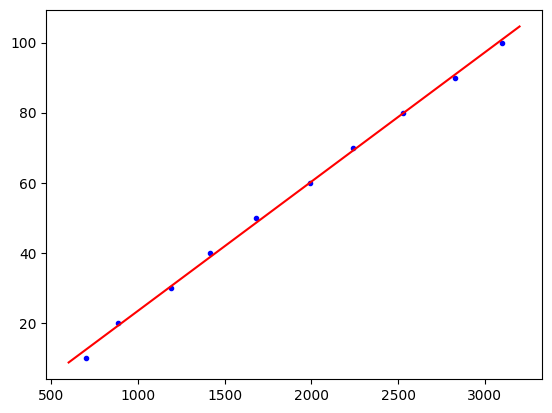

 a = 0.03688
 b = -13.43215


In [3]:
# verwerk hier jullie kalibratiemetingen
kalibratie_bits = np.array([700,886,1189,1413,1680,1992,2242,2530,2825,3100 ])
kalibratie_afstand = np.array([10,20,30,40,50,60,70,80,90,100])


def function(x,a,b):
    return a*x+b

values, covariance = curve_fit(function,kalibratie_bits,kalibratie_afstand)

x_fit = np.linspace(600,3200,300)

plt.figure()
plt.plot(kalibratie_bits,kalibratie_afstand,'b.')
plt.plot(x_fit, function(x_fit,*values),'r-')
plt.show()
print(f' a = {values[0]:.5f}')
print(f' b = {values[1]:.5f}')

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  45.65
1   0  30   0  20  45.02
2  40   0  30   0  40.00
3  30   0  20   0  40.74


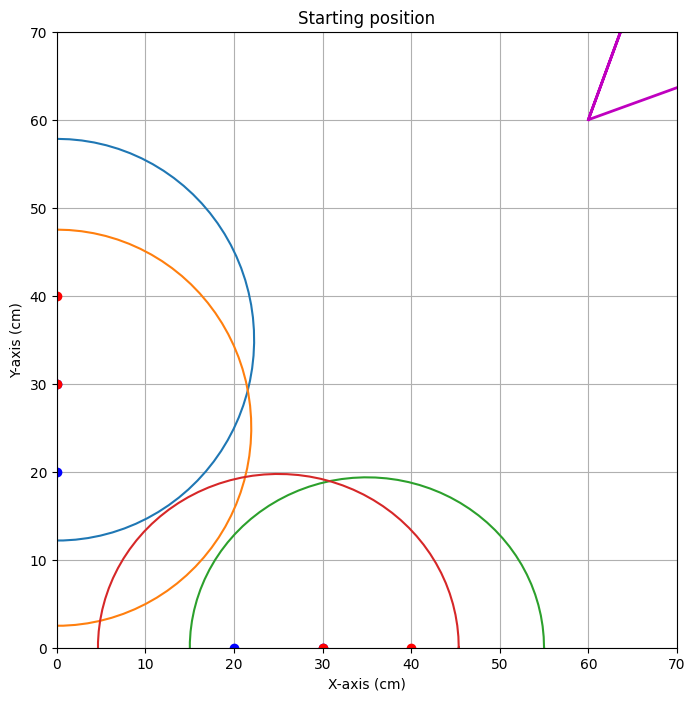


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.102


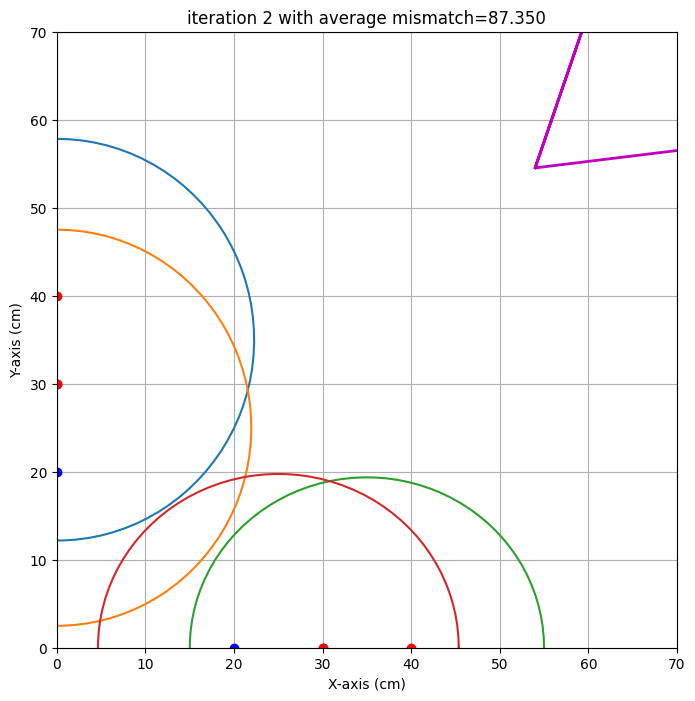

end iteration 2 with average mismatch=87.350


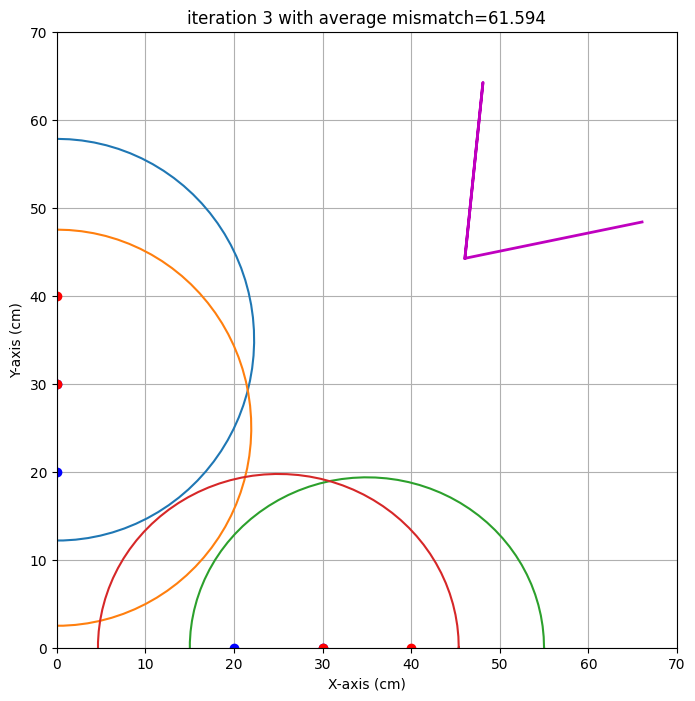

end iteration 3 with average mismatch=61.594


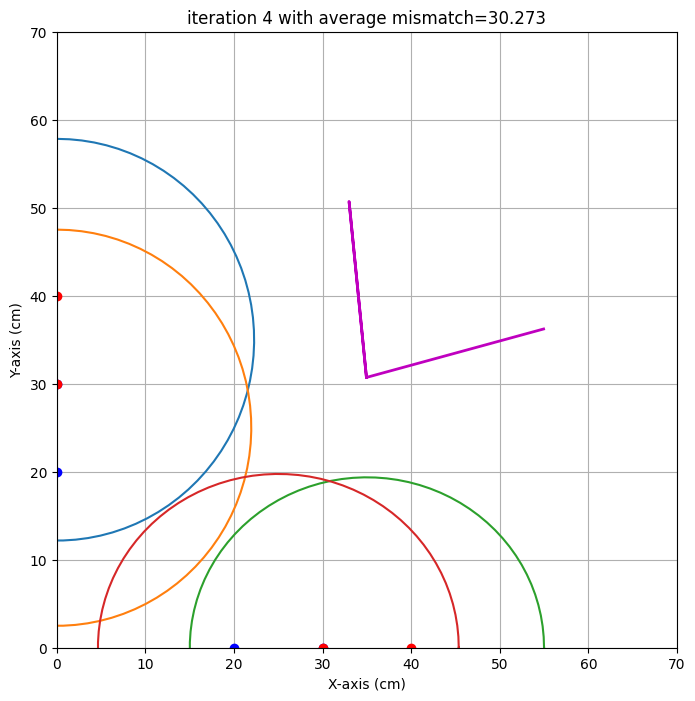

end iteration 4 with average mismatch=30.273


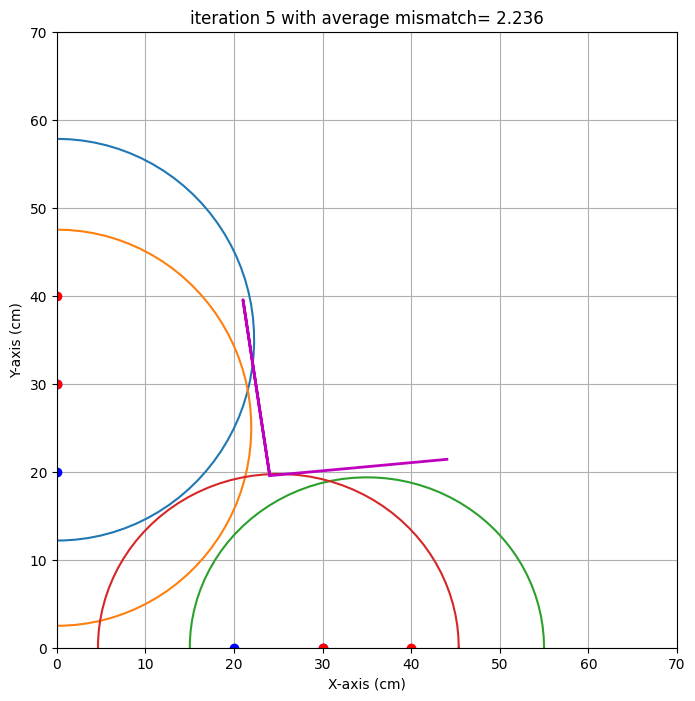

end iteration 5 with average mismatch= 2.236


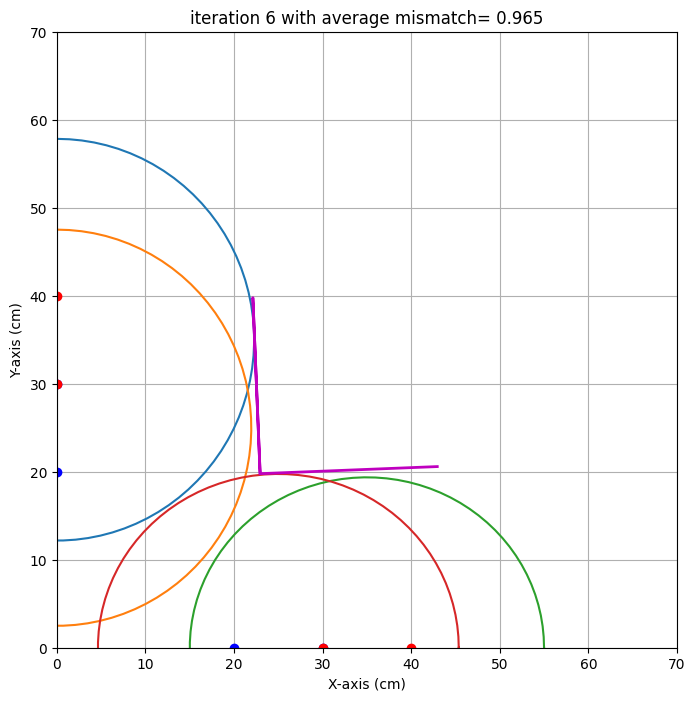

end iteration 6 with average mismatch= 0.965


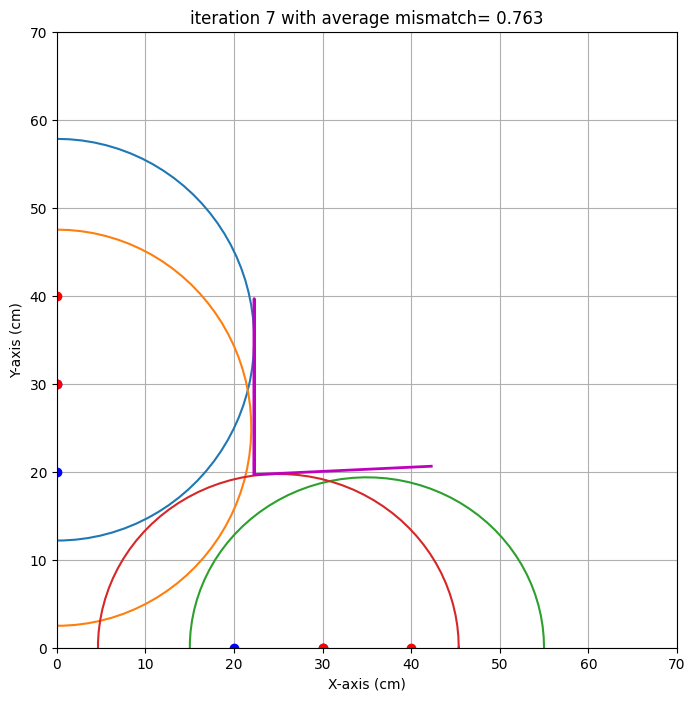

end iteration 7 with average mismatch= 0.763


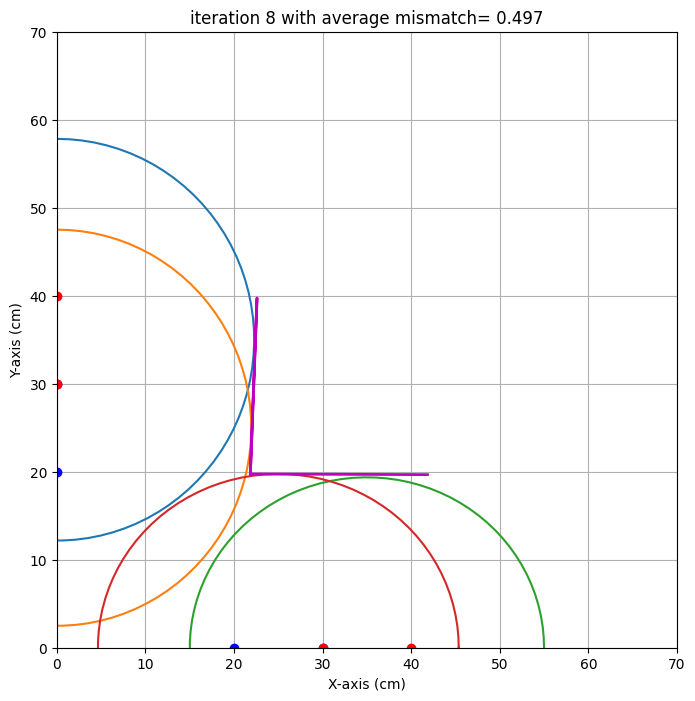

end iteration 8 with average mismatch= 0.497


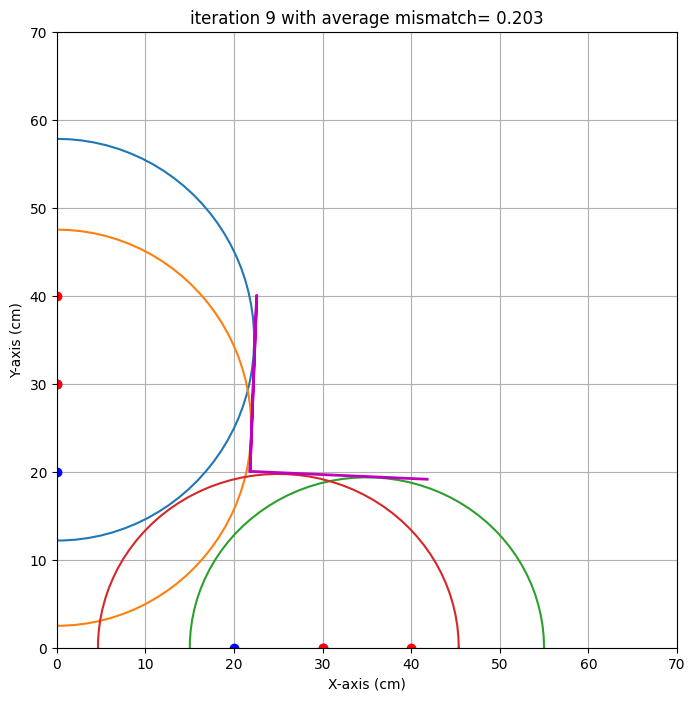

end iteration 9 with average mismatch= 0.203


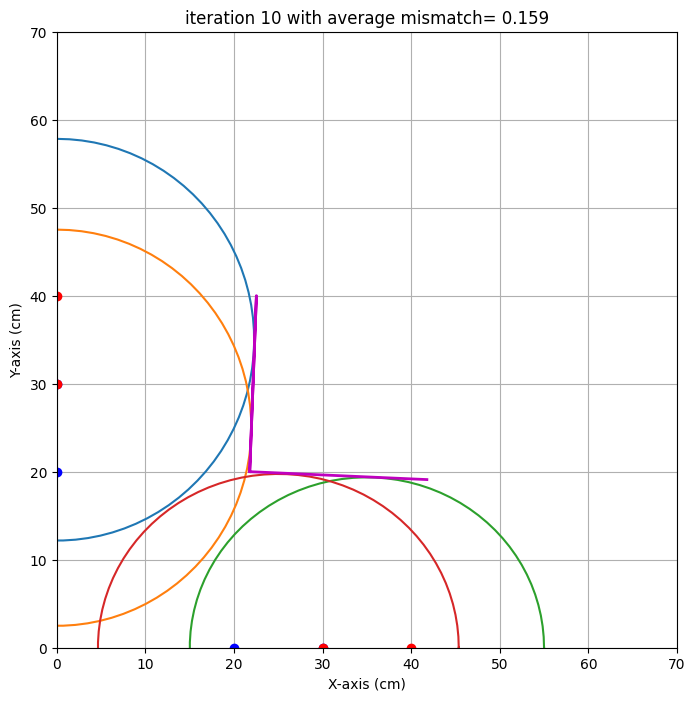

end iteration 10 with average mismatch= 0.159
end iteration 11 with average mismatch= 0.158
end iteration 12 with average mismatch= 0.157
end iteration 13 with average mismatch= 0.157
end iteration 14 with average mismatch= 0.157
end iteration 15 with average mismatch= 0.157
end iteration 16 with average mismatch= 0.157
end iteration 17 with average mismatch= 0.157
end iteration 18 with average mismatch= 0.157
end iteration 19 with average mismatch= 0.157
end iteration 20 with average mismatch= 0.157
end iteration 21 with average mismatch= 0.157
end iteration 22 with average mismatch= 0.157
end iteration 23 with average mismatch= 0.157
end iteration 24 with average mismatch= 0.157
end iteration 25 with average mismatch= 0.157
end iteration 26 with average mismatch= 0.157
end iteration 27 with average mismatch= 0.157
end iteration 28 with average mismatch= 0.157
end iteration 29 with average mismatch= 0.157
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

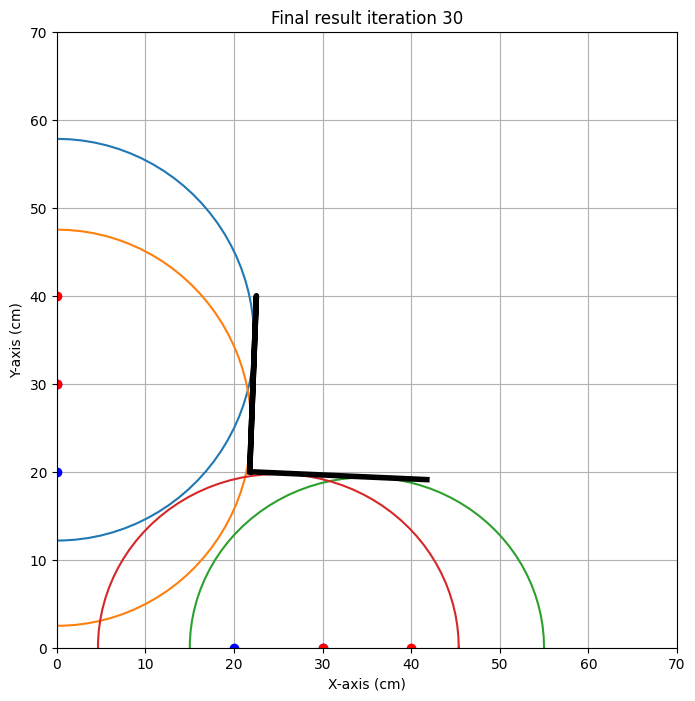

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,45.65],
    [0,30,0,20,45.02],
    [40,0,30,0,40],
    [30,0,20,0,40.74],  
    ])
# [10,0,0,10,]  meting buiten beschouwing gelaten omdat hier de hoek wordt gemeten.
# [10,0,20,0,43.2], 
# 
resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.8 cm met een standaardafwijking van 0.0 cm 
y0: 20.0 cm met een standaardafwijking van 0.0 cm 
alpha: -2.6 graden met een standaardafwijking van 0.0 graad 
beta: 2.2 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Siemen Spek]
<img src="eerste_algoritme_siemen.jpeg" width="400">

#### algoritme [Batu Sönmez]
<img src="eerste_algoritme_batu.jpeg" width="400">

#### algoritme [Tom Jongbloed]
<img src="eerste_algoritme_tom.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':40,  
           'y0': 45,
           'alpha' : 25,
           'beta' : 30,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Siemen Spek' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [0,30,0,35, ongeldig],
    # [0,45,0,50,ongeldig],
    [60,0,65,0, 93],
    [50,0,60,0, 88],
    #[30,0,35,0,ongeldig],
    [0,45,0,50,93],
    [0,50,0,55,90],
    # siemen
    ]),
       'Tom Jongbloed' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [65,0,55,0,87],
      [55,0,45,0,88.65],
      [0,75,0,65,102.3],
      [0,65,0,55,97],
    # tom
    ]),
       'Batu Sönmez' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ])
      }

## Opdracht 7: Evaluatie.

Siemen Spek
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  60   0  65   0  93
1  50   0  60   0  88
2   0  45   0  50  93
3   0  50   0  55  90


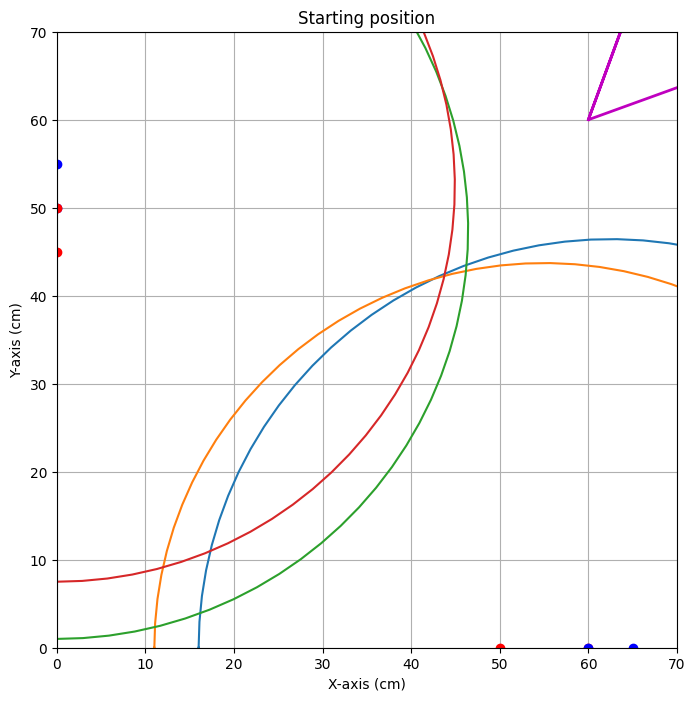


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=36.254


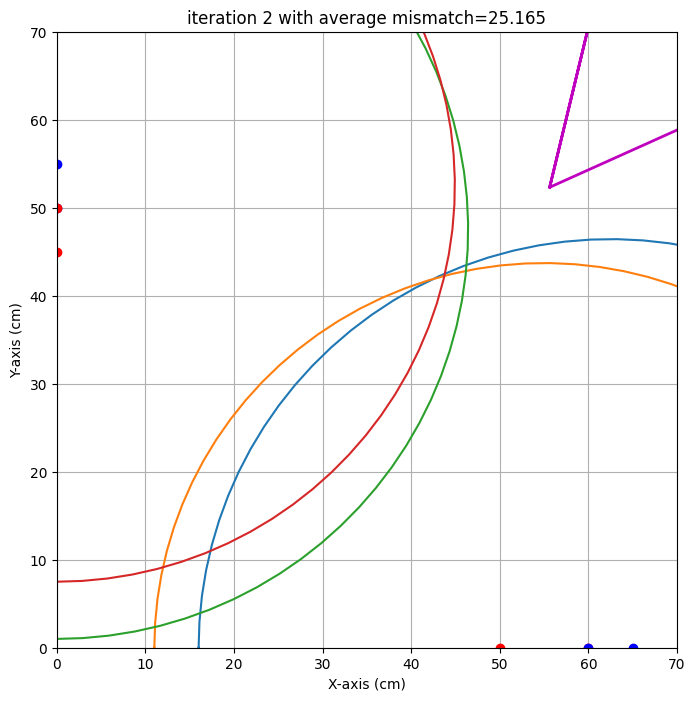

end iteration 2 with average mismatch=25.165


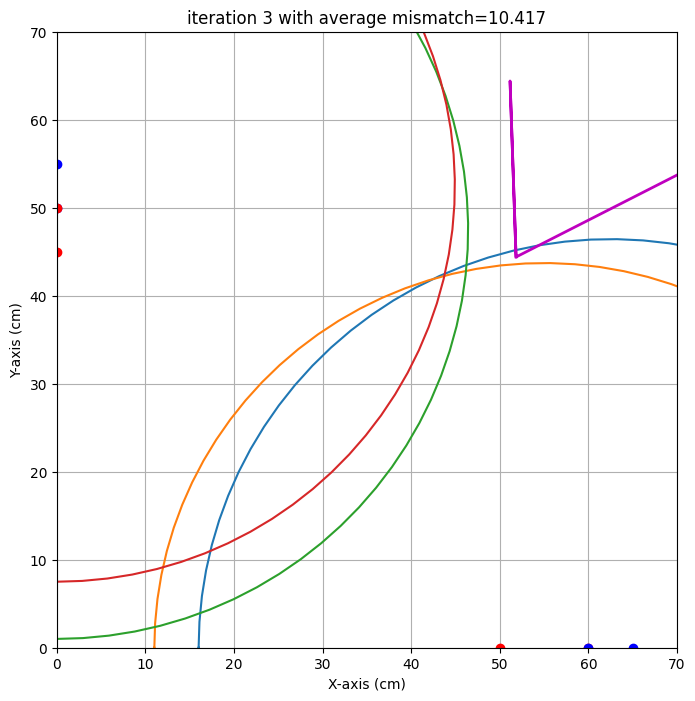

end iteration 3 with average mismatch=10.417


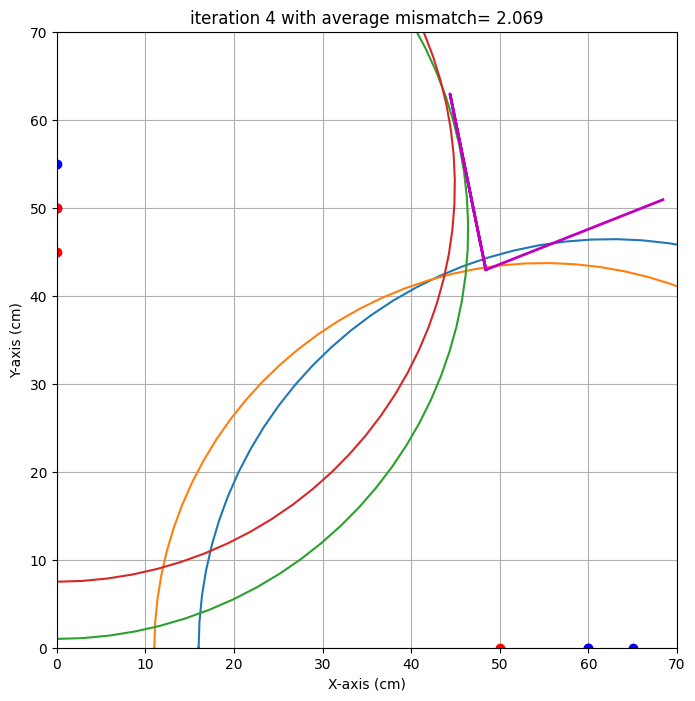

end iteration 4 with average mismatch= 2.069


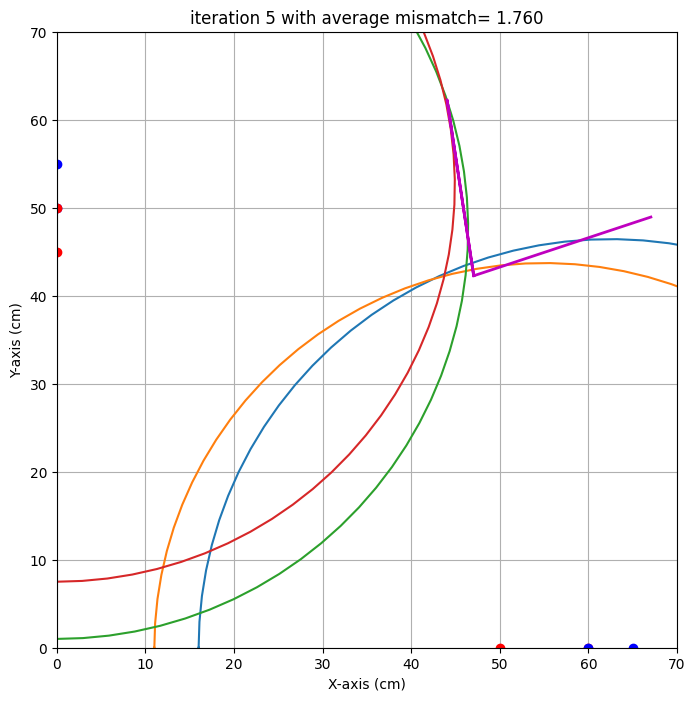

end iteration 5 with average mismatch= 1.760


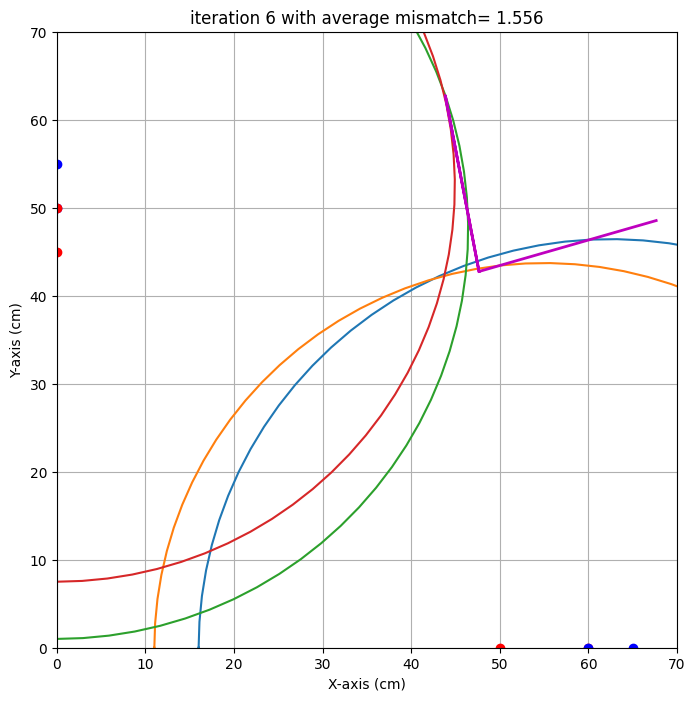

end iteration 6 with average mismatch= 1.556
end iteration 7 with average mismatch= 1.431
end iteration 8 with average mismatch= 1.396
end iteration 9 with average mismatch= 1.278
end iteration 10 with average mismatch= 1.274
end iteration 11 with average mismatch= 1.274
end iteration 12 with average mismatch= 1.274
end iteration 13 with average mismatch= 1.274
end iteration 14 with average mismatch= 1.200
end iteration 15 with average mismatch= 1.200
end iteration 16 with average mismatch= 1.200
end iteration 17 with average mismatch= 1.158
end iteration 18 with average mismatch= 1.147
end iteration 19 with average mismatch= 1.136
end iteration 20 with average mismatch= 1.088
end iteration 21 with average mismatch= 1.071
end iteration 22 with average mismatch= 1.059
end iteration 23 with average mismatch= 1.059
end iteration 24 with average mismatch= 1.059
end iteration 25 with average mismatch= 1.059
end iteration 26 with average mismatch= 1.059
end iteration 27 with average mismatch

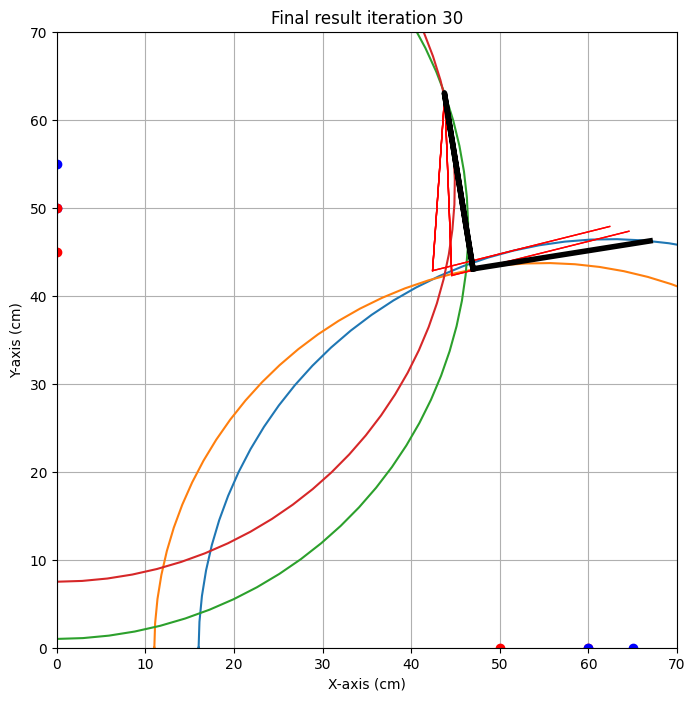

{'alpha': np.float64(9.029826434320503), 'alpha_eps': np.float64(5.077932862821635), 'beta': np.float64(-9.181488530382431), 'beta_eps': np.float64(13.12267432077158), 'x0': np.float64(46.97806698165768), 'x0_eps': np.float64(4.565793297602767), 'y0': np.float64(43.05289049932507), 'y0_eps': np.float64(0.7542741943486533)}
Tom Jongbloed
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0  65   0  55   0   87.00
1  55   0  45   0   88.65
2   0  75   0  65  102.30
3   0  65   0  55   97.00


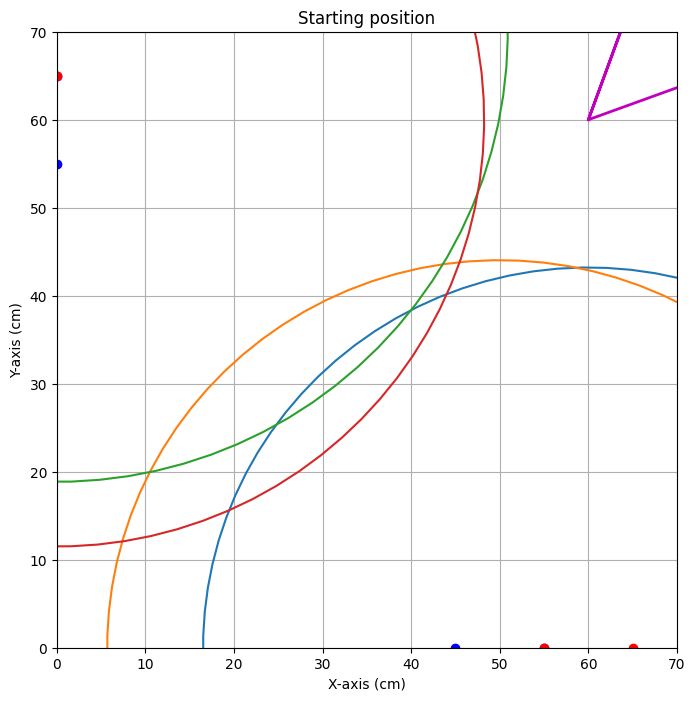


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=32.468


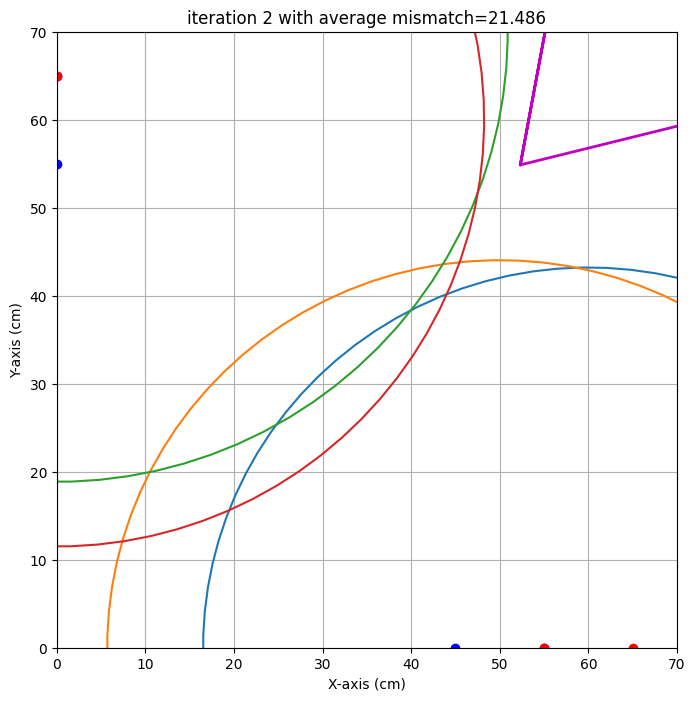

end iteration 2 with average mismatch=21.486


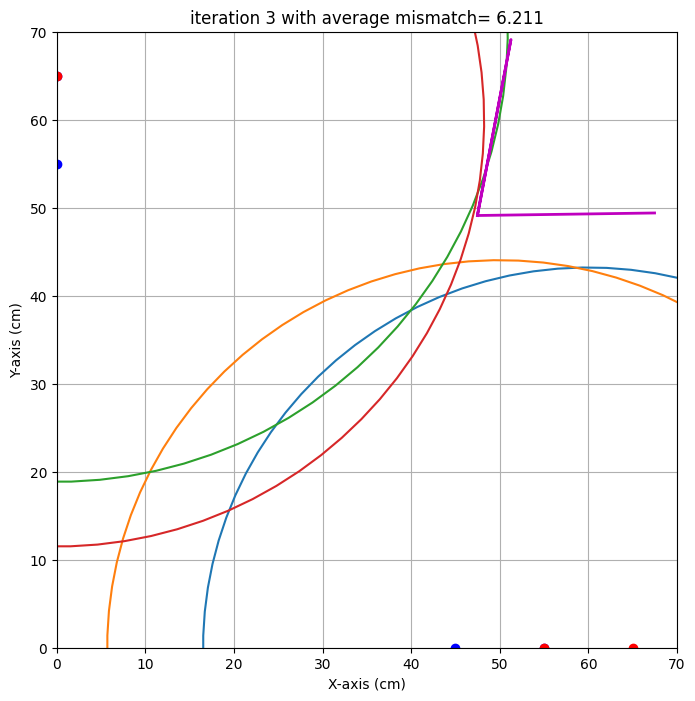

end iteration 3 with average mismatch= 6.211


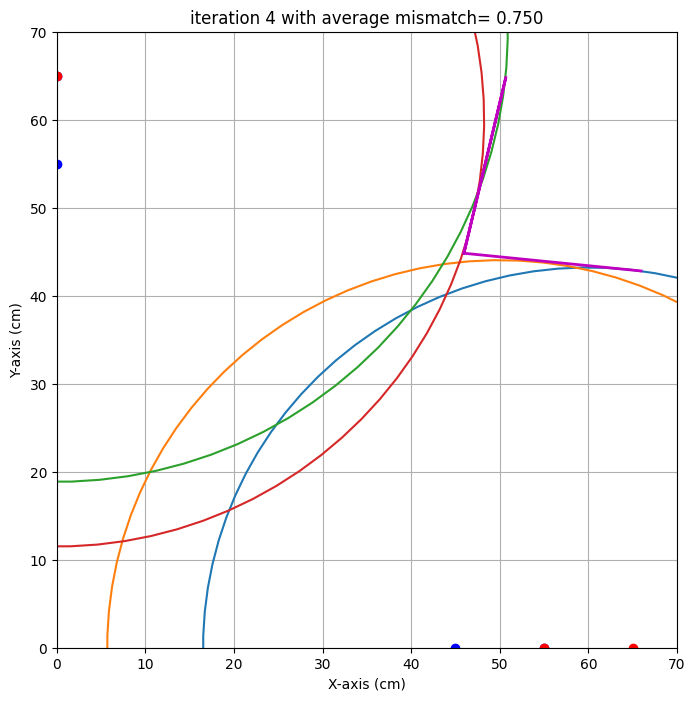

end iteration 4 with average mismatch= 0.750


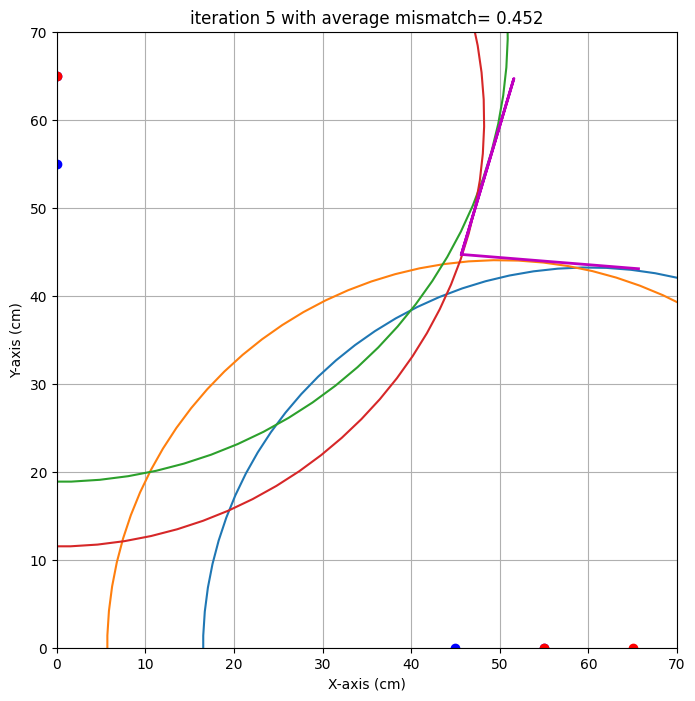

end iteration 5 with average mismatch= 0.452


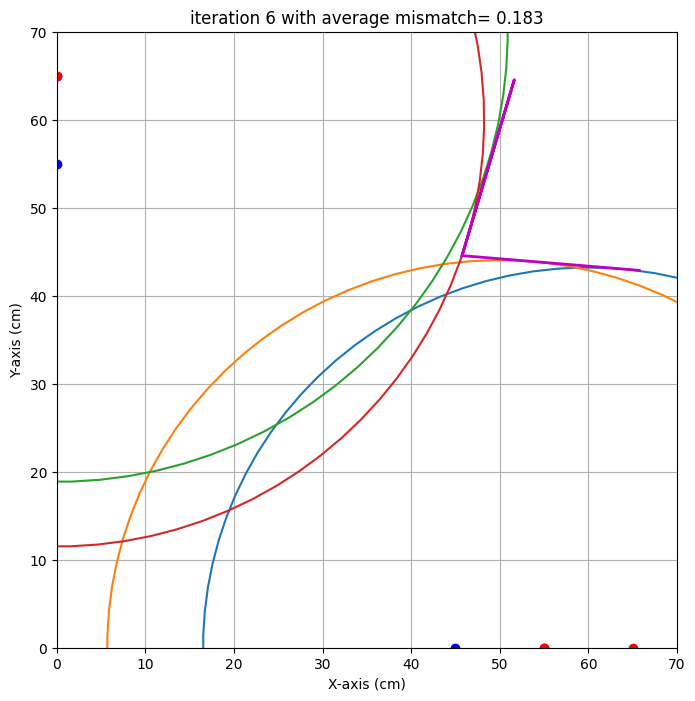

end iteration 6 with average mismatch= 0.183
end iteration 7 with average mismatch= 0.182
end iteration 8 with average mismatch= 0.182
end iteration 9 with average mismatch= 0.182
end iteration 10 with average mismatch= 0.182
end iteration 11 with average mismatch= 0.182
end iteration 12 with average mismatch= 0.182
end iteration 13 with average mismatch= 0.182
end iteration 14 with average mismatch= 0.182
end iteration 15 with average mismatch= 0.182
end iteration 16 with average mismatch= 0.182
end iteration 17 with average mismatch= 0.182
end iteration 18 with average mismatch= 0.182
end iteration 19 with average mismatch= 0.182
end iteration 20 with average mismatch= 0.182
end iteration 21 with average mismatch= 0.182
end iteration 22 with average mismatch= 0.182
end iteration 23 with average mismatch= 0.182
end iteration 24 with average mismatch= 0.182
end iteration 25 with average mismatch= 0.182
end iteration 26 with average mismatch= 0.182
end iteration 27 with average mismatch

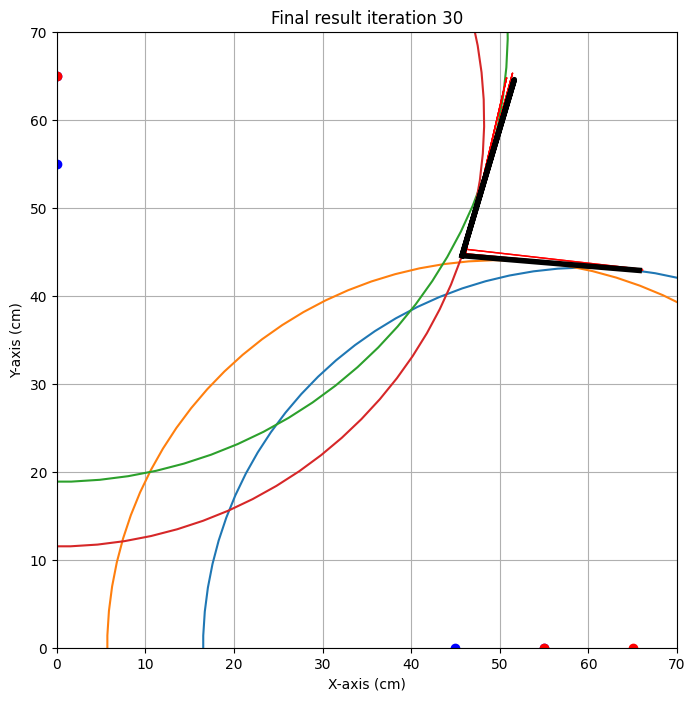

{'alpha': np.float64(-4.789307423183693), 'alpha_eps': np.float64(1.7304374091846757), 'beta': np.float64(16.4387779603753), 'beta_eps': np.float64(3.3221990123591), 'x0': np.float64(45.74250777560133), 'x0_eps': np.float64(0.37662534124718405), 'y0': np.float64(44.55509439151142), 'y0_eps': np.float64(0.7396945840369327)}
Batu Sönmez
Running the imaging algorithm with the following data:
Empty DataFrame
Columns: [xs, ys, xr, yr, R]
Index: []


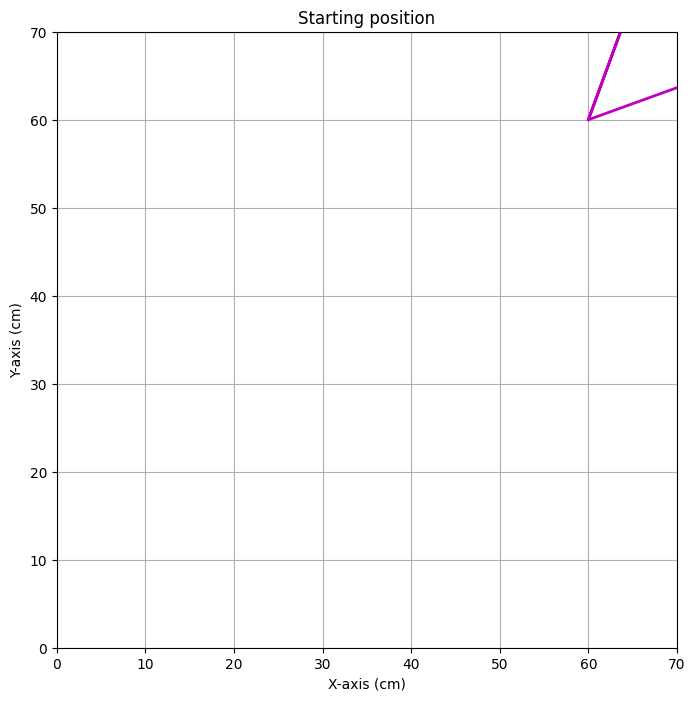


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan


c:\Users\sieme\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\sieme\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:146: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with average mismatch=   nan
end iteration 22 with average mismatch=   nan
end iteration 23 with average mismatch=   nan
end iteration 24 with average mismatch=   nan
end iteration 25 with average mismatch=   nan
end iteration 26 with average mismatch=   nan
end iteration 27 with average mismatch=   nan
end iteration 28 with average mismatch=   nan
end iteration 29 with average mismatch=   nan
Last iteration, also determine unce

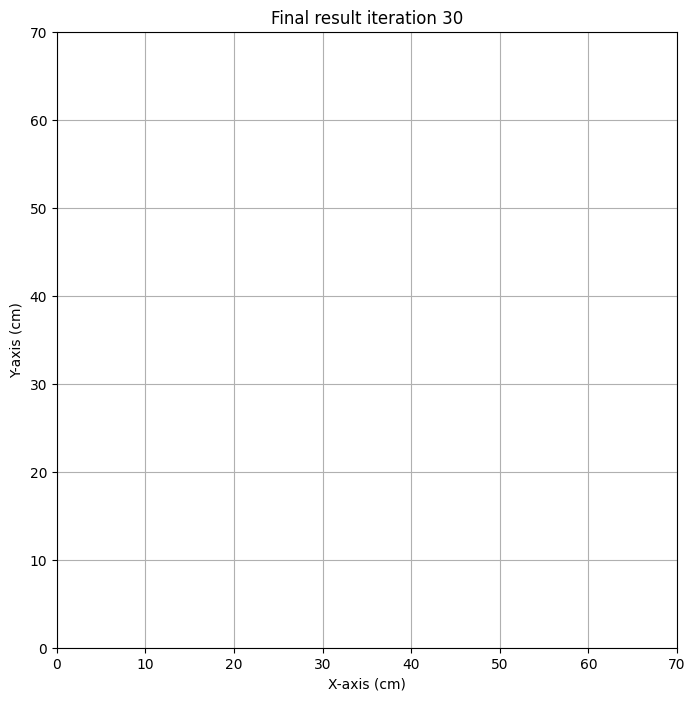

{'alpha': np.float64(nan), 'alpha_eps': 0.0, 'beta': np.float64(nan), 'beta_eps': 0.0, 'x0': np.float64(nan), 'x0_eps': 0.0, 'y0': np.float64(nan), 'y0_eps': 0.0}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Siemen Spek 
x0 target is : 40.0. Gevonden waarde: 47.0 cm met een standaardafwijking van 4.6 cm 
y0 target is : 45.0. Gevonden waarde: 43.1 cm met een standaardafwijking van 0.8 cm 
alpha target is : 25.0. Gevonden waarde: 9.0 graden met een standaardafwijking van 5.1 graad 
beta target is : 30.0. Gevonden waarde: -9.2 graden met een standaardafwijking van 13.1 graad 

Tom Jongbloed 
x0 target is : 40.0. Gevonden waarde: 45.7 cm met een standaardafwijking van 0.4 cm 
y0 target is : 45.0. Gevonden waarde: 44.6 cm met een standaardafwijking van 0.7 cm 
alpha target is : 25.0. Gevonden waarde: -4.8 graden met een standaardafwijking van 1.7 graad 
beta target is : 30.0. Gevonden waarde: 16.4 graden met een standaardafwijking van 3.3 graad 

Batu Sönmez 
x0 target is : 40.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 45.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : 25.0. Gevonden waarde: nan graden met een standaardaf

## Opdracht 8: Iteratie1+.14.45.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_einde.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  70   0  60  68.18
1   0  75   0  60  70.00
2   0  65   0  55  66.40
3   0  65   0  50  65.12
4  55   0  45   0  68.10
5  55   0  40   0  69.66


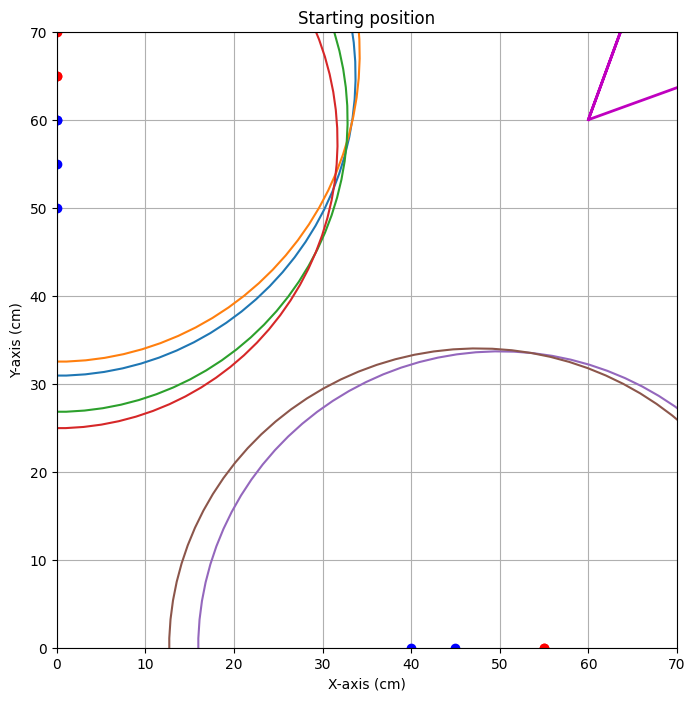


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.378


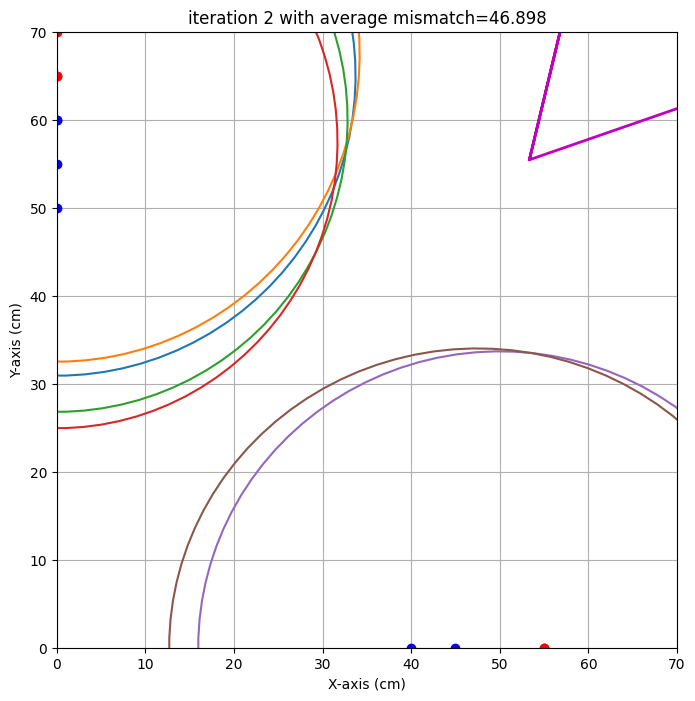

end iteration 2 with average mismatch=46.898


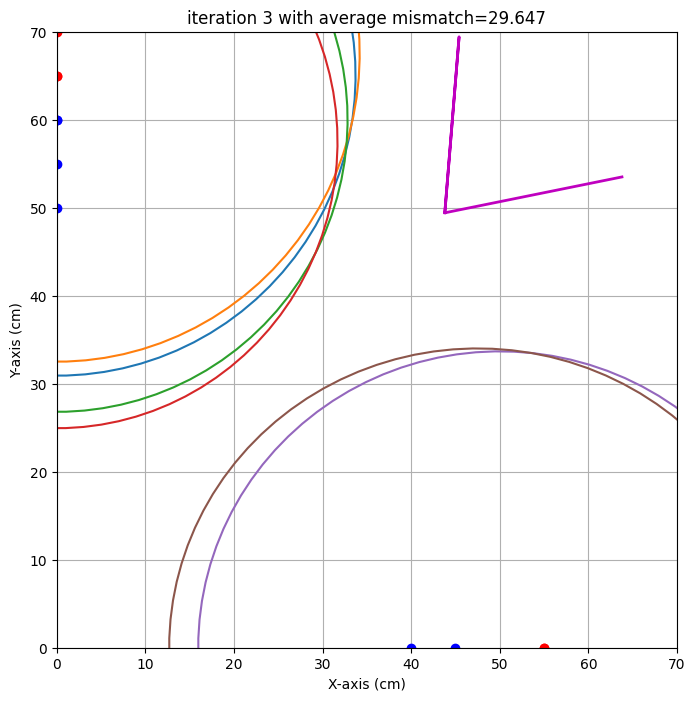

end iteration 3 with average mismatch=29.647


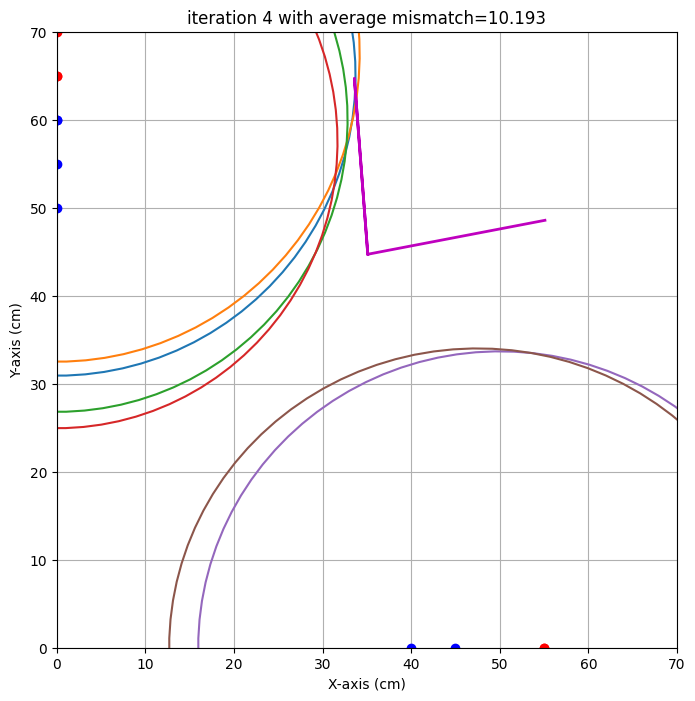

end iteration 4 with average mismatch=10.193


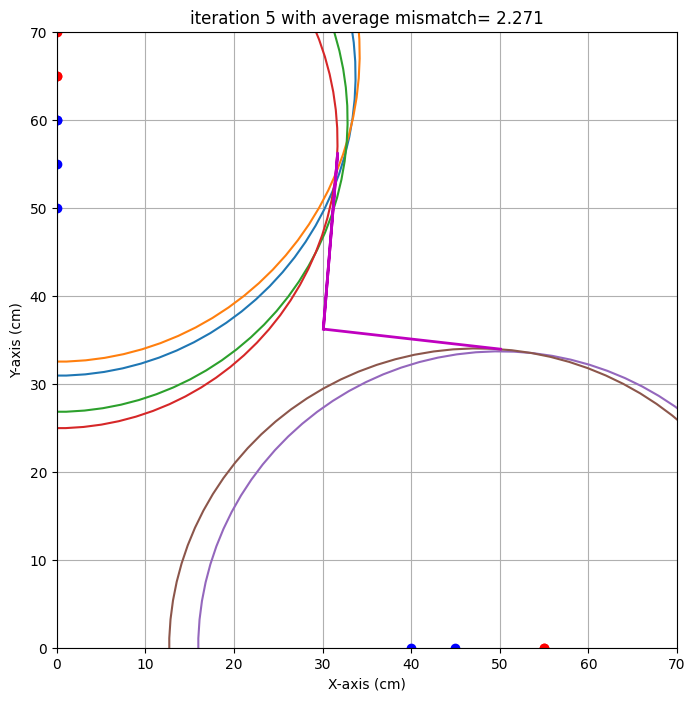

end iteration 5 with average mismatch= 2.271


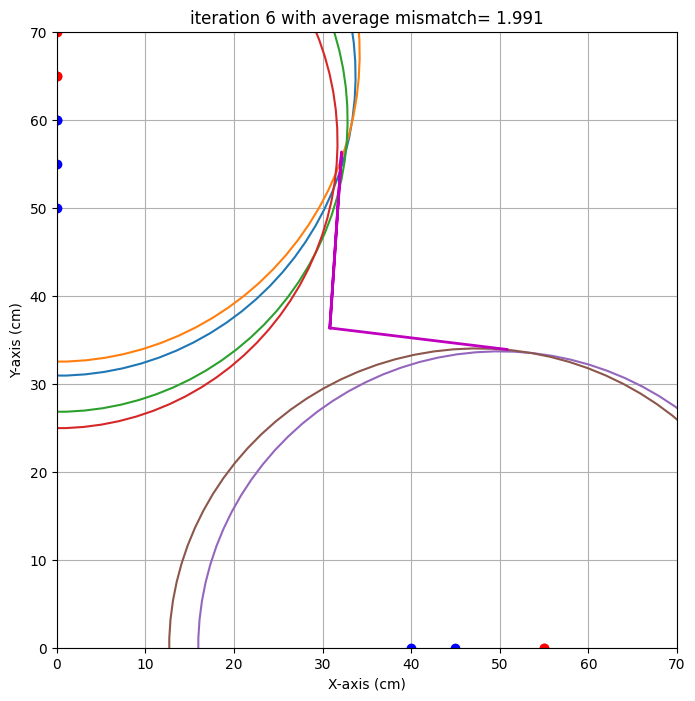

end iteration 6 with average mismatch= 1.991
end iteration 7 with average mismatch= 1.986
end iteration 8 with average mismatch= 1.965
end iteration 9 with average mismatch= 1.965
end iteration 10 with average mismatch= 1.867
end iteration 11 with average mismatch= 1.851
end iteration 12 with average mismatch= 1.851
end iteration 13 with average mismatch= 1.751
end iteration 14 with average mismatch= 1.738
end iteration 15 with average mismatch= 1.737
end iteration 16 with average mismatch= 1.737
end iteration 17 with average mismatch= 1.737
end iteration 18 with average mismatch= 1.695
end iteration 19 with average mismatch= 1.695
end iteration 20 with average mismatch= 1.695
end iteration 21 with average mismatch= 1.695
end iteration 22 with average mismatch= 1.695
end iteration 23 with average mismatch= 1.695
end iteration 24 with average mismatch= 1.695
end iteration 25 with average mismatch= 1.695
end iteration 26 with average mismatch= 1.695
end iteration 27 with average mismatch

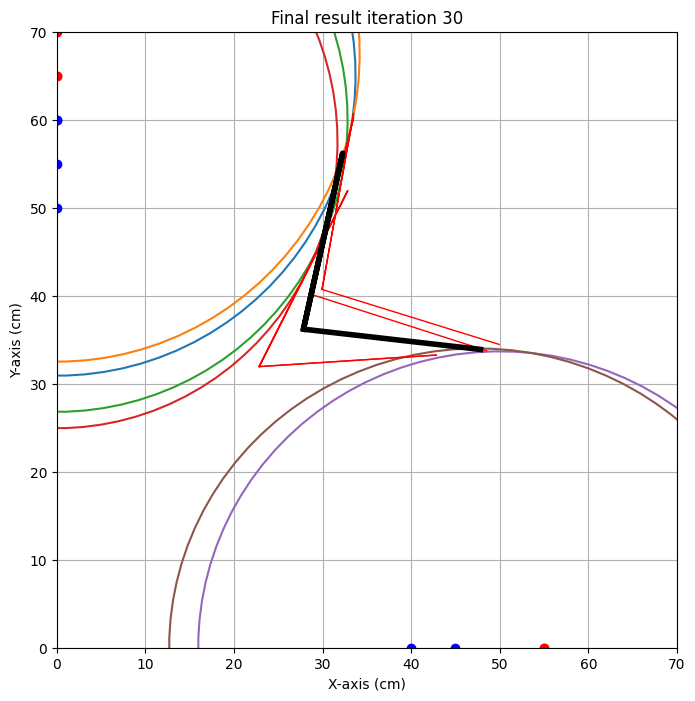

{'alpha': np.float64(-6.567704039945923), 'alpha_eps': np.float64(11.35342096657618), 'beta': np.float64(12.499596978987078), 'beta_eps': np.float64(14.073036858457996), 'x0': np.float64(27.832201154722355), 'x0_eps': np.float64(4.999806220647724), 'y0': np.float64(36.19820099388938), 'y0_eps': np.float64(4.516019642544656)}
locatie 1 
x0 target is : 27.0. Gevonden waarde: 27.8 cm met een standaardafwijking van 5.0 cm 
y0 target is : 35.0. Gevonden waarde: 36.2 cm met een standaardafwijking van 4.5 cm 
alpha target is : -26.0. Gevonden waarde: -6.6 graden met een standaardafwijking van 11.4 graad 
beta target is : 20.0. Gevonden waarde: 12.5 graden met een standaardafwijking van 14.1 graad 



In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 27,
                    'y0': 35,
                    'alpha' : -26,
                    'beta' : 20,                  
           'locatie 2':{'x0':34,
                    'y0':34,
                    'alpha' :34, 
                    'beta' :34, 
            }}}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,70,0,60,68.18],
    [0,75,0,60,70],
    [0,65,0,55,66.4],
    [0,65,0,50,65.12],
    # [60,0,50,0,79],
    # [65,0,50,0,ongeldig],
    [55,0,45,0,68.1],
    [55,0,40,0,69.66],
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  55   0  45  53.0
1   0  50   0  40  48.5
2   0  50   0  35  51.0
3  45   0  35   0  45.0
4  50   0  35   0  44.9
5  40   0  30   0  47.0
6  40   0  25   0  49.2


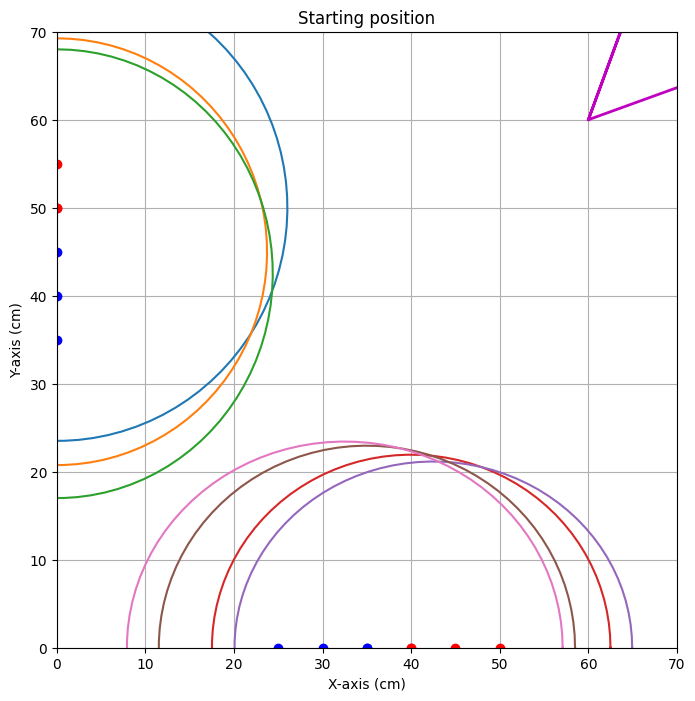


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.182


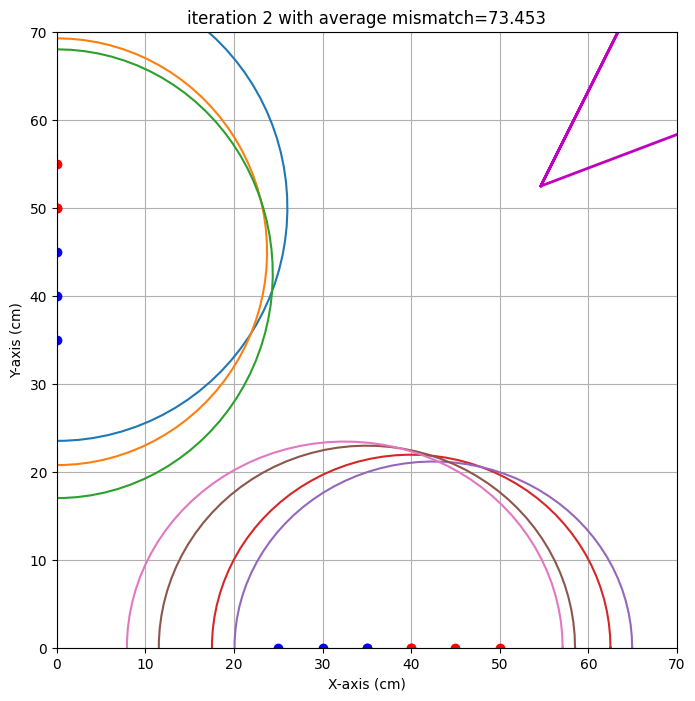

end iteration 2 with average mismatch=73.453


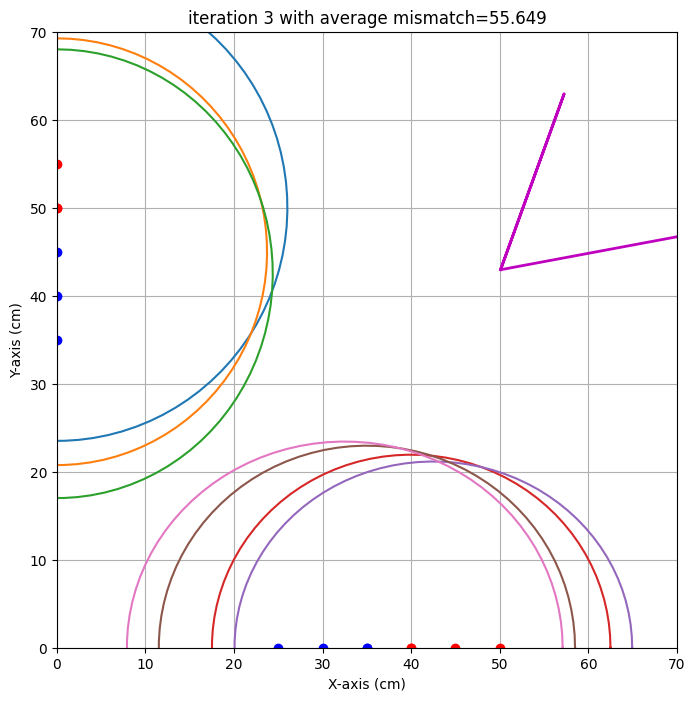

end iteration 3 with average mismatch=55.649


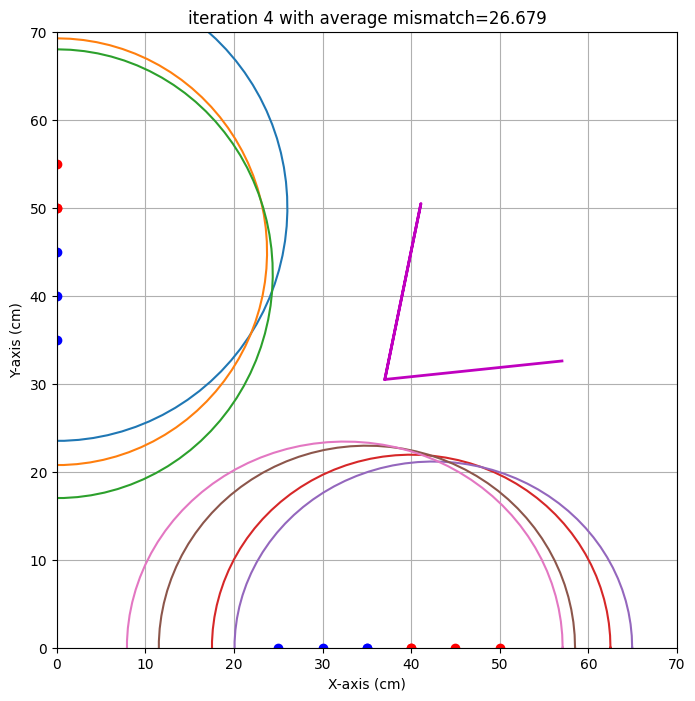

end iteration 4 with average mismatch=26.679


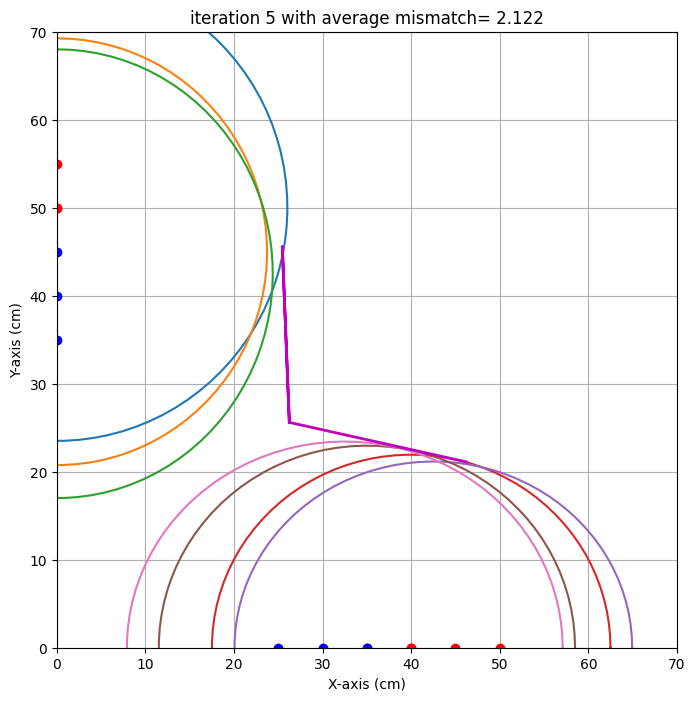

end iteration 5 with average mismatch= 2.122
end iteration 6 with average mismatch= 1.939
end iteration 7 with average mismatch= 1.938
end iteration 8 with average mismatch= 1.822
end iteration 9 with average mismatch= 1.822
end iteration 10 with average mismatch= 1.822
end iteration 11 with average mismatch= 1.822


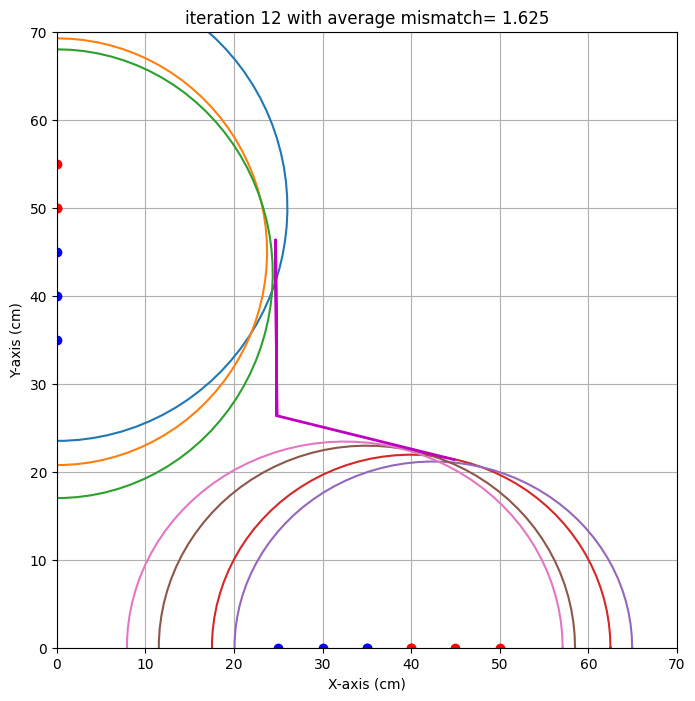

end iteration 12 with average mismatch= 1.625
end iteration 13 with average mismatch= 1.493
end iteration 14 with average mismatch= 1.491
end iteration 15 with average mismatch= 1.490
end iteration 16 with average mismatch= 1.478
end iteration 17 with average mismatch= 1.408
end iteration 18 with average mismatch= 1.395
end iteration 19 with average mismatch= 1.394
end iteration 20 with average mismatch= 1.394
end iteration 21 with average mismatch= 1.388
end iteration 22 with average mismatch= 1.375
end iteration 23 with average mismatch= 1.375
end iteration 24 with average mismatch= 1.375
end iteration 25 with average mismatch= 1.375
end iteration 26 with average mismatch= 1.375
end iteration 27 with average mismatch= 1.375
end iteration 28 with average mismatch= 1.375
end iteration 29 with average mismatch= 1.375
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.375
#################

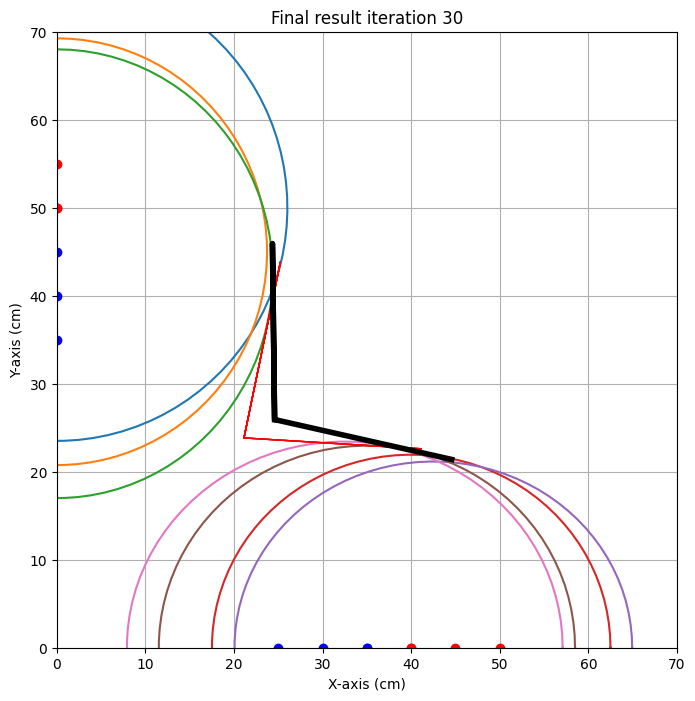

{'alpha': np.float64(-12.770539628059765), 'alpha_eps': np.float64(9.24740420101059), 'beta': np.float64(-0.6923508922371127), 'beta_eps': np.float64(12.317252625007075), 'x0': np.float64(24.576621558918003), 'x0_eps': np.float64(3.454615476486186), 'y0': np.float64(25.927263015216077), 'y0_eps': np.float64(2.0857710431615075)}
test locatie 
x0 target is : 25.6. Gevonden waarde: 24.6 cm met een standaardafwijking van 3.5 cm 
y0 target is : 26.2. Gevonden waarde: 25.9 cm met een standaardafwijking van 2.1 cm 
alpha target is : -15.0. Gevonden waarde: -12.8 graden met een standaardafwijking van 9.2 graad 
beta target is : -2.0. Gevonden waarde: -0.7 graden met een standaardafwijking van 12.3 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 25.6 ,
                    'y0': 26.2 ,
                    'alpha' : -15 ,
                    'beta' :  -2
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # [0,70,0,60,ongeldig],
                    # [0,55,0,45,56],
                    # [0,60,0,45,ongeldig],
                    # [0,50,0,40,51.2],
                    # [0,50,0,35,54],
                    # [60,0,50,0,ongeldig],
                    # [45,0,35,0,47],
                    # [50,0,35,0,47.5],
                    # [40,0,30,0,50],
                    # [40,0,25,0,52],
                    # tweede metingen:
                    # [0,70,0,60,ongeldig],
                    [0,55,0,45,53],
                    [0,50,0,40,48.5],
                    [0,50,0,35,51],
                    # [60,0,50,0,ongeldig],
                    [45,0,35,0,45],
                    [50,0,35,0,44.9],
                    [40,0,30,0,47],
                    [40,0,25,0,49.2],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

De blauwe ellips valt deze buiten onze waarden, omdat wij hierbij precies de rand meten. Dit zorgt ervoor dat wij de targetwaarden niet dicht genoeg vinden met onze metingen

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](eerste_algoritme_siemen.jpeg "Title")
evaluaties:
werkte niet goed, geeft heel andere hoeken dan gemeten. Vooral verschillende afstanden tussen bron en ontvanger toevoegen.

Figuur: ![Alt](iteratie_1.jpeg "Title")
evaluaties: komt in de buurt, nog steeds hoeken niet goed bepaald, dus nog meer metingen met kleine variatie in afstand tussen bron en ontvanger.

Figuur: ![Alt](algoritme_einde.jpeg "Title")

onze uiteindelijke meetopstelling:
Figuur: ![Alt](uiteindelijke_meetopstelling.jpeg "Title")